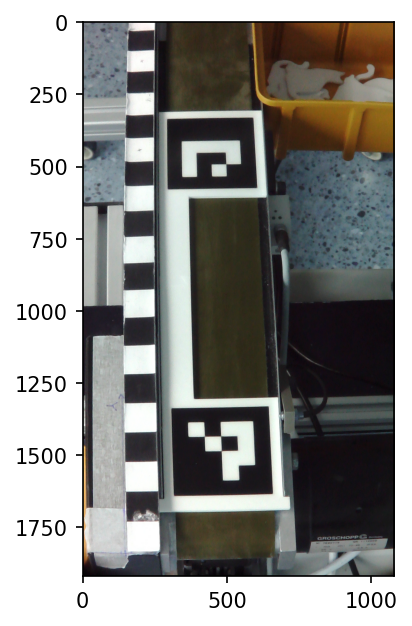

In [1]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from cv2 import aruco
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('test/aruco_pic/aruco_0.png')
#img_aruco = cv.imread('first_image.png')

img_aruco_rotated = cv.rotate(img_aruco,2)
#img_aruco_rotated = cv.flip(img_aruco_rotated, 1)

# Test Bild
img_obj = cv.imread('test/obj/cat/foto_15.png')
#img_obj = cv.imread('test/obj/unicorn/foto_19.png')

img_obj_rotated = cv.rotate(img_obj,2)
#img_obj_rotated = cv.flip(img_obj,1)


SRC_COORDS = (np.array([[[ -44.,  246.],  [-102., 244.],   [-102., 304.],  [ -44.,304.], 
                                [ -44., 222 + 246.], [-102., 222 + 246.], [-102., 282. + 244], [ -44., 282. + 244]]], dtype= np.float32))


SRC_COORDS_2 = np.array([[[0.246, -0.044], [0.244, -0.102], [0.304, -0.102], [0.304, -0.044],
                          [0.468, -0.044], [0.466, -0.102], [0.526, -0.102], [0.528, -0.044]]], dtype=np.float32)

x1_initial = 246. # mm
y1_initial = -44. # mm

x2_initial = 244. # mm
y2_initial = -102. # mm

x3_initial = 304. # mm
y3_initial = -102. # mm

offset_second_marker_1 = 222.
offset_second_marker_2 = 282.

SRC_COORDS_3 = (np.array([[[y1_initial, x1_initial],  [y2_initial, x2_initial],  [y3_initial, x3_initial],  [x1_initial, x3_initial], 
                                [y1_initial, x1_initial + offset_second_marker_1], [y2_initial, x2_initial + offset_second_marker_1], [y2_initial, x2_initial + offset_second_marker_2], [y1_initial, x1_initial + offset_second_marker_2]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

(array([[[ 307., 1340.],
        [ 642., 1333.],
        [ 656., 1636.],
        [ 314., 1640.]]], dtype=float32), array([[[292., 339.],
        [589., 335.],
        [601., 578.],
        [293., 581.]]], dtype=float32))


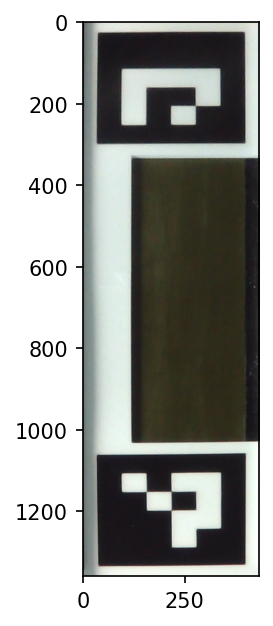

In [2]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

print(corners)

ids_list = ids.flatten().tolist()

if 1 not in ids_list or 0 not in ids_list:
    print('Fehler: Die benötigten Marker (ID 1 und ID 0) sind nicht beide im Bild!')

idx_1 = ids_list.index(1)
idx_0 = ids_list.index(0)

sorted_corners = [corners[idx_1], corners[idx_0]]

dstPoints = np.concatenate(sorted_corners, axis=1)

H_pre, _ = cv.findHomography(srcPoints=SRC_COORDS_2, dstPoints=dstPoints, method=0)
H_pre_inv = np.linalg.inv(H_pre)

pts1 = np.float32([
    sorted_corners[0][0][0],  # ID 1 (oben-links)
    sorted_corners[0][0][1],  # ID 1 (oben-rechts)
    sorted_corners[1][0][3],  # ID 0 (unten-links)
    sorted_corners[1][0][2],  # ID 0 (unten-rechts)
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

world_frame = cv.perspectiveTransform(pts1_reshaped, H_pre_inv)

offset_raw = np.array([
    [-0.006, +0.006],  # mm - X offset -6, Y offset -6
    [-0.006, -0.006],  # mm - X offset +6, Y offset -6
    [+0.006, +0.006],  # mm - X offset -6, Y offset +6
    [+0.006, -0.006]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

pts1_2_pixel = cv.perspectiveTransform(pts1_2, H_pre)

min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M_for_all = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

img_warped = cv.warpPerspective(img_aruco_rotated, M_for_all, (width, height))
plt.imshow(img_warped)

In [3]:
corners, ids, rejected = detector.detectMarkers(img_warped)

dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS_2, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

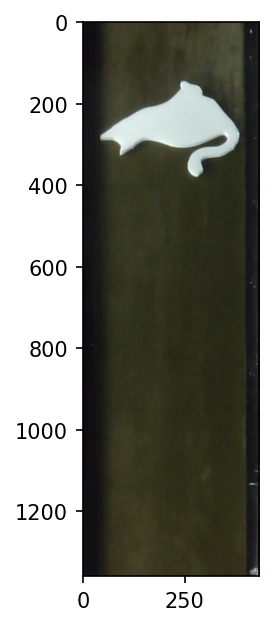

In [4]:
dst_obj = cv.warpPerspective(img_obj_rotated, M_for_all, (width, height))
plt.imshow(dst_obj)

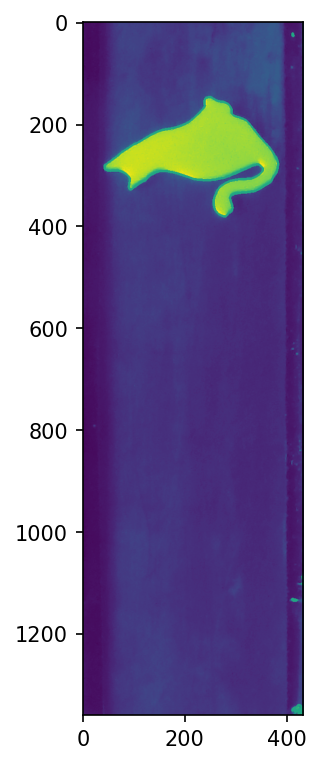

In [12]:
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 200, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours_obj , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours_obj, contourIdx= -1 , color= (155, 155, 155),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours)

In [6]:
model = joblib.load("decision_tree.joblib")

In [7]:
def extract_hu2_hu3_features(cnt):
    features = {}

    M_moments = cv.moments(cnt)
    if M_moments["m00"] == 0:
        return None

    hu_raw = cv.HuMoments(cv.moments(cnt)).flatten()

    with np.errstate(divide="ignore"):

        hu_log = -np.sign(hu_raw) * np.log10(np.abs(hu_raw) + 1e-10)

    features["hu_2"] = float(hu_log[2])  
    features["hu_3"] = float(hu_log[3])

    return features

In [8]:
selected_features = ["hu_2", "hu_3"] 

cnt = max(contours_obj, key=cv.contourArea)

features = extract_hu2_hu3_features(cnt)

X_new = pd.DataFrame([features])[selected_features]  # ["hu_2", "hu_3"]

prediction = model.predict(X_new)
print("Erkannte Klasse:", prediction[0])

proba = model.predict_proba(X_new)
print("Konfidenz:", dict(zip(model.classes_, proba[0].round(2))))

Erkannte Klasse: cat
Konfidenz: {'cat': 1.0, 'rejected': 0.0, 'unicorn': 0.0}


# Position

In [9]:
def obj_position(contours):
    if not contours:
        print("Keine Konturen gefunden")
        return None

    largest_contour = max(contours, key=cv.contourArea)
    M = cv.moments(largest_contour)
    if M["m00"] == 0:
        return None

    cX = int(M["m10"] / M["m00"])  
    cY = int(M["m01"] / M["m00"])  
    return (cX, cY)


def pixel_to_world(pixel):
    if pixel is None:
        print("no pixel")
        return None

    pixel_array = np.array([pixel], dtype=np.float32).reshape(-1, 1, 2)
    world = cv.perspectiveTransform(pixel_array, H_inv)
    print(world[0, 0])
    return world[0, 0]

In [10]:
x = pixel_to_world(obj_position(contours_obj))

x

[ 0.49058387 -0.07600284]


array([ 0.49058387, -0.07600284], dtype=float32)

In [11]:


t=pixel_to_world(obj_position(contours_obj))
print("t")

[ 0.49058387 -0.07600284]
t
